# **02477 Bayesian Machine Learning | Comprehensive study notes**



---

<div class="alert alert-block alert-warning">

### **Imports**
</div>

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
from jax import random, grad, value_and_grad

jax.config.update("jax_enable_x64", True) 
import scipy as sc
from scipy.stats import norm                          # 1D Gaussian
from scipy.stats import multivariate_normal as mvn    # multivariate Gaussian
from scipy.stats import beta as beta_dist
from scipy.stats import binom as binom_dist
from scipy.stats import betabinom
from scipy.stats import poisson
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import seaborn as snb
snb.set_style('darkgrid')
snb.set_theme(font_scale=1.)

from time import time
from dataclasses import dataclass

<a id='bonus_a'></a>

<div class="alert alert-block alert-warning">


### **Bonus A | Log-likelihood cookbook**

Standard distributions you must be able to write down instantly.
</div>

##### **A.1 Likelihoods**


<span style="color: blue;">

| Model | Log-likelihood $\ln p(y\|\theta)$ |
|---|---|
| **Gaussian regression** $y_n \mid w \sim \mathcal{N}(w^T\phi_n, \sigma^2)$ | $-\frac{N}{2}\ln(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_n(y_n - w^T\phi_n)^2$ |
| **Binary classification** $y_n \mid w \sim \text{Ber}(\sigma(w^T\phi_n))$ | $\sum_n[y_n \ln\sigma(f_n) + (1{-}y_n)\ln(1{-}\sigma(f_n))]$ |
| **Poisson regression** $y_n \mid \mu_n \sim \text{Pois}(e^{w^Tx_n})$ | $\sum_n[y_n w^Tx_n - e^{w^Tx_n} - \ln(y_n!)]$ |
| **GP regression** $y \mid f \sim \mathcal{N}(f, \sigma^2 I)$ | $-\frac{N}{2}\ln(2\pi) - \frac{1}{2}\ln\vert K{+}\sigma^2 I\vert - \frac{1}{2}y^T(K{+}\sigma^2 I)^{-1}y$ |

</span>

##### **A.1.1 Notation guide**



<span style="color: red;">

| Symbol | Meaning |
|---|---|
| $y_n \in \mathbb{R}$ | Scalar observation for data point $n$ |
| $\mathbf{y} \in \mathbb{R}^N$ | Full vector of $N$ observations |
| $w \in \mathbb{R}^D$ | Weight/parameter vector |
| $\phi_n = \phi(x_n) \in \mathbb{R}^D$ | Feature vector (basis function) for input $x_n$ |
| $\Phi \in \mathbb{R}^{N \times D}$ | Design matrix - row $n$ is $\phi_n^T$ |
| $f_n = w^T\phi_n$ | Predicted mean for data point $n$ |
| $\sigma^2$ | Noise variance (fixed scalar) |
| $\sigma(\cdot)$ | Sigmoid function $\sigma(a) = \frac{1}{1+e^{-a}}$ |
| $K \in \mathbb{R}^{N \times N}$ | GP kernel (covariance) matrix, $K_{ij} = k(x_i, x_j)$ |
| $k(x, x')$ | Kernel function - measures similarity between inputs |
| $\alpha$ | Prior precision (i.e. prior is $\mathcal{N}(w \mid 0, \alpha^{-1}I)$) |
| $\beta = 1/\sigma^2$ | Noise precision |
| $m, S$ | Posterior mean and covariance of $w$ |
| $\hat{w}_\text{MAP}$ | MAP estimate - maximiser of $\log p(y, w)$ |
| $H$ | Hessian of $\log p(y, w)$ at $\hat{w}_\text{MAP}$ |
| $A = -H$ | Negative Hessian (positive definite at a maximum) |
| $S = A^{-1} = (-H)^{-1}$ | Laplace posterior covariance |
| $q(w)$ | Variational / approximate posterior |
| $\mathcal{L}$ | ELBO (evidence lower bound) |
| $H[q]$ | Entropy of $q$ |
| $m_i, v_i$ | Mean-field variational mean and variance for $w_i$ |
| $\mu(\theta)$ | Mean that **depends on parameters** - must expand $(y - \mu(\theta))^2$, never use shortcut formula |

</span>

##### **A.2 Log-priors**


<span style="color: blue;">


| Prior | Log-prior $\ln p(\theta)$ |
|---|---|
| Gaussian $w \sim \mathcal{N}(0, \alpha^{-1}I)$ | $-\frac{\alpha}{2}w^Tw + \text{const}$ |
| GP prior $f \sim \mathcal{N}(0, K)$ | $-\frac{1}{2}f^TK^{-1}f - \frac{1}{2}\ln \|K \| + \text{const}$ |
| Beta $\theta \sim \text{Beta}(a,b)$ | $(a-1)\ln\theta + (b-1)\ln(1-\theta) + \text{const}$ |

</span>

##### **A.2.1 Notation guide**




<span style="color: red;">

| Symbol | Meaning |
|---|---|
| $w \in \mathbb{R}^D$ | Weight vector - the parameter being given a prior |
| $\alpha > 0$ | Prior precision - larger $\alpha$ = stronger regularisation toward zero |
| $\alpha^{-1}$ | Prior variance - $p(w) = \mathcal{N}(w \mid 0, \alpha^{-1}I)$ |
| $f \in \mathbb{R}^N$ | Vector of GP function values at training inputs |
| $K \in \mathbb{R}^{N \times N}$ | GP prior covariance matrix, $K_{ij} = k(x_i, x_j)$ |
| $\|K\|$ | Determinant of $K$ |
| $\theta \in [0,1]$ | Beta-distributed scalar (e.g. a probability) |
| $a, b > 0$ | Beta hyperparameters - shape parameters controlling concentration |
| $\text{const}$ | Any term not depending on the variable of interest -  safe to drop when differentiating or pattern-matching |

</span>

##### **A.3 How to find MAP - universal recipe**


```python
from scipy.optimize import minimize

def neg_log_joint(theta):
    log_lik  = ...  # sum of log p(yn | theta)
    log_prior = ...  # log p(theta)
    return -(log_lik + log_prior)

res = minimize(neg_log_joint, theta_init, method='BFGS')
theta_MAP = res.x
```

##### **A.4 How to verify MAP (exam Question 3.1 pattern)**


1. **Gradient check:** $\nabla_\theta \ln p(y,\theta)|_{\hat{\theta}} \approx 0$
2. **Hessian check:** $\nabla^2_\theta \ln p(y,\theta)|_{\hat{\theta}}$ should be negative definite
3. **Perturbation check:** any small step from $\hat{\theta}$ should decrease the log-joint


<a id='bonus_b'></a>

<div class="alert alert-block alert-warning">

### **Bonus B | Linear Gaussian systems (exam 2024 Part 1 pattern)**

Markov chains, state-space models, Gaussian conditioning
</div>

##### **B.1 Gaussian conditioning formula (must memorise!)**


<span style="color: blue;">

$$\begin{bmatrix}y_1\\y_2\end{bmatrix} \sim \mathcal{N}\!\left(\begin{bmatrix}\mu_1\\\mu_2\end{bmatrix}, \begin{bmatrix}\Sigma_{11} & \Sigma_{12}\\\Sigma_{21} & \Sigma_{22}\end{bmatrix}\right)$$

$$\boxed{p(y_1|y_2) = \mathcal{N}(y_1 \mid \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(y_2{-}\mu_2),\; \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21})}$$

</span>

Where in the conditioning formula $p(y_1 \mid y_2)$:

<span style="color: red;">

> $y_1$ is the variable we want to condition on (the "query")

> $y_2$ is the observed variable (the "evidence")  

> $\mu_1, \mu_2$ are the prior means of $y_1$ and $y_2$

> $\Sigma_{12} = \text{Cov}(y_1, y_2)$ - cross-covariance, often the hardest to compute

> $\Sigma_{22}$ is the marginal covariance of $y_2$ - what we are conditioning on

> $\Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$ is the **Schur complement** - posterior variance is always smaller than prior variance

</span>

##### **B.2 Linear Gaussian chain - recipes**


Model: $x_1 \sim \mathcal{N}(0,\Sigma)$, $\;x_2|x_1 \sim \mathcal{N}(Ax_1,\Sigma)$, $\;x_3|x_2 \sim \mathcal{N}(Ax_2,\Sigma)$

| Quantity | Distribution |
|---|---|
| $p(x_2)$ | $\mathcal{N}(0,\; A\Sigma A^T + \Sigma)$ |
| $p(x_3)$ | $\mathcal{N}(0,\; A^2\Sigma A^{2T} + A\Sigma A^T + \Sigma)$ |
| $p(x_3 \|x_1)$ | $\mathcal{N}(A^2 x_1,\; A\Sigma A^T + \Sigma)$ |
| $p(x_1 \|x_2)$ | Use conditioning formula on joint $(x_1,x_2)$ |

**Joint** $(x_1, x_2)$ covariance matrix:
$$\text{Cov}(x_1, x_2) = \Sigma A^T \qquad \text{(since } x_2 = Ax_1 + \epsilon, \; x_1 \perp \epsilon)$$

**Key rule:** For $y = Ax + \epsilon$ with $x \perp \epsilon$:

> $\mathbb{E}[y] = A\,\mathbb{E}[x]$

> $\text{Cov}(y) = A\,\text{Cov}(x)\,A^T + \text{Cov}(\epsilon)$

> $\text{Cov}(x, y) = \text{Cov}(x)\,A^T$

And for the linear Gaussian chain $y = Ax + \epsilon$:

> $A$ is the linear transformation matrix

> $\epsilon$ is independent noise with its own covariance

> $\text{Cov}(x, y) = \text{Cov}(x)\,A^T$ - the cross-covariance is always this form when $y$ is a linear function of $x$

> The joint is always Gaussian - stack $\begin{bmatrix}x \\ y\end{bmatrix}$ and apply the conditioning formula to get any conditional

##### **B.3 General joint construction, any linear Gaussian chain**



When the exam gives you a non-standard chain (e.g. $z = Ax + b + n_1$, $y = Wz + n_2$ as in 2025R Part 1), do not look for a recipe. Build the joint from scratch in three steps.

**Step 1: Propagate means.** Apply $\mathbb{E}[\cdot]$ through each equation, using linearity:
$$\mathbb{E}[z] = A\,\mathbb{E}[x] + b + \mathbb{E}[n_1] = A\mu_x + b$$
$$\mathbb{E}[y] = W\,\mathbb{E}[z] = W(A\mu_x + b)$$

**Step 2: Propagate covariances.** For any $v = Cu + \epsilon$ with $u \perp \epsilon$:
$$\text{Cov}(v) = C\,\text{Cov}(u)\,C^T + \text{Cov}(\epsilon)$$
$$\text{Cov}(u, v) = \text{Cov}(u)\,C^T$$

Apply sequentially. Example for 2025R Part 1 ($x \sim \mathcal{N}(0,I)$, $n_1 \sim \mathcal{N}(0,\frac{1}{2}I)$, $n_2 \sim \mathcal{N}(0,\frac{1}{2}I)$):
$$\text{Cov}(z) = A\,I\,A^T + \tfrac{1}{2}I \qquad \text{Cov}(x,z) = I\cdot A^T = A^T$$
$$\text{Cov}(y) = W\,\text{Cov}(z)\,W^T + \tfrac{1}{2}I \qquad \text{Cov}(z,y) = \text{Cov}(z)\,W^T$$

**Step 3: Stack and condition.** To find any conditional, write the joint as:
$$\begin{bmatrix} u \\ v \end{bmatrix} \sim \mathcal{N}\!\left(\begin{bmatrix}\mu_u\\\mu_v\end{bmatrix}, \begin{bmatrix}\Sigma_{uu} & \Sigma_{uv}\\\Sigma_{vu} & \Sigma_{vv}\end{bmatrix}\right)$$
then apply the conditioning formula from B.1 directly.

**What tells you to use this procedure:** the question gives you a chain of linear equations with additive Gaussian noise and asks for any of $p(z|x)$, $p(x|z)$, $p(y)$, $p(y|x)$, etc.

<a id='bonus_c'></a>

<div class="alert alert-block alert-warning">

### **Bonus C | Gaussian identities quick-ref**

Completing the square, KL divergences, entropy, marginalisation
</div>


##### **C.1 Completing the square**


**1D:**

If $\ln q(w) = -\frac{a}{2}w^2 + bw + \text{const}$ then $q(w) = \mathcal{N}(w \mid \frac{b}{a}, \frac{1}{a})$

**Multivariate:**

If $\ln q(w) = -\frac{1}{2}w^T P w + r^T w + \text{const}$ then $q(w) = \mathcal{N}(w \mid P^{-1}r,\, P^{-1})$



<span style="color: red;">

> $a$ is the coefficient of $w^2$ (the precision - always positive at a mode)

> $b$ is the coefficient of $w$ (the "linear term")

> $P$ is the precision matrix (inverse covariance) - read it off as the matrix in front of $w^Tw$

> $r$ is the vector of linear coefficients - read off as the vector multiplying $w$

</span>

##### **C.2 Key identities**


| Identity | Formula |
|---|---|
| **Linear transform** | $y = Ax+b$, $x\sim\mathcal{N}(\mu,\Sigma)$ $\Rightarrow$ $y\sim\mathcal{N}(A\mu+b, A\Sigma A^T)$ |
| **Marginalisation** | $x\|\theta\sim\mathcal{N}(A\theta,\Sigma)$, $\theta\sim\mathcal{N}(\mu,\Lambda)$ $\Rightarrow$ $x\sim\mathcal{N}(A\mu, \Sigma+A\Lambda A^T)$ |
| **KL (univariate)** | $\text{KL}[\mathcal{N}(m,v)\|\mathcal{N}(0,1)] = \frac{1}{2}(v+m^2-1-\ln v)$ |
| **Entropy (1D)** | $H[\mathcal{N}(\mu,\sigma^2)] = \frac{1}{2}\ln(2\pi e\,\sigma^2)$ |
| **Entropy (multivariate)** | $H[\mathcal{N}(\mu,\Sigma)] = \frac{D}{2}\ln(2\pi e) + \frac{1}{2}\ln\vert\Sigma\vert$ |
| **Entropy (mean-field)** | $H[\prod_i \mathcal{N}(m_i,v_i)] = \sum_i \frac{1}{2}\ln(2\pi e\,v_i)$ |


<span style="color: red;">

> $\theta$ is the latent variable being marginalised out

> $A$ maps $\theta$ to the mean of $x$ - so $\mathbb{E}[x] = A\mu$

> The marginal variance $\Sigma + A\Lambda A^T$ = noise variance + propagated parameter uncertainty

> **Special case:** $A = I$ gives $x \sim \mathcal{N}(\mu, \Sigma + \Lambda)$ - just add variances

</span>

##### **C.3 Prior predictive distributions**


For **Bayesian LR** with prior $w \sim \mathcal{N}(0, \alpha^{-1}I)$:
$$p(y^*|x^*) = \mathcal{N}\!\left(y^* | 0,\; (\phi^*)^T(\alpha^{-1}I)\phi^* + \sigma^2\right)$$

For **GP regression** with kernel $k$:
$$p(y^*|x^*) = \mathcal{N}\!\left(y^* | 0,\; k(x^*,x^*) + \sigma^2\right)$$

> **Key pattern with "prior variance at $x^*$":** whenever the exam asks for the *prior* distribution of $f(x^*)$ or $y(x^*)$, the answer is just $k(x^*,x^*)$ (plus $\sigma^2$ if observation noise is included). No data, no posterior formula — just evaluate the kernel at the test point with itself.

For **GP binary classification, THE CANONICAL FORMULA** (use $\frac{8}{\pi}$, always):

$$\boxed{p(y^*{=}1|y, x^*) \approx \Phi\!\left(\frac{\mu_{f^*}}{\sqrt{\frac{8}{\pi} + \sigma^2_{f^*}}}\right)}$$

**Prior predictive** (plug in $\mu_{f^*}=0$, $\sigma^2_{f^*}=k(x^*,x^*)$):
$$p(y^*{=}1|x^*) = \Phi\!\left(\frac{0}{\sqrt{\frac{8}{\pi} + k(x^*,x^*)}}\right) = 0.5$$
*(Always 0.5 when prior mean = 0, regardless of kernel)*

**Posterior predictive** (plug in $\mu_{f^*}$ and $\sigma^2_{f^*}$ from the Laplace approximation):
$$\mu_{f^*} = k_*^T K^{-1} m \qquad \sigma^2_{f^*} = k(x^*,x^*) - k_*^T(K + \Lambda^{-1})^{-1}k_*$$

> **Ignore any formula we see written as $\sqrt{1 + \frac{\pi}{8}\sigma^2_{f^*}}$** because that is from a different approximation. The weekly notebooks and this course use $\frac{8}{\pi}$ in the denominator. Memorise only the boxed formula above.


<span style="color: red;">

> $k_* \in \mathbb{R}^N$ - vector of kernel evaluations between test point $x^*$ and all training points, $k_* = [k(x^*, x_1), \ldots, k(x^*, x_N)]^T$

> $K \in \mathbb{R}^{N \times N}$ - training kernel matrix

> $m \in \mathbb{R}^N$ - posterior mean of $f$ at training points (from Laplace approximation)

> $\Lambda$ - diagonal matrix from Laplace approximation of the GP classifier posterior, $\Lambda_{nn} = \pi_n(1-\pi_n)$ where $\pi_n = \sigma(m_n)$
> $\mu_{f^*}$ - posterior mean of the latent function at $x^*$

> $\sigma^2_{f^*}$ - posterior variance of the latent function at $x^*$

> $\Phi(\cdot)$ - probit function (CDF of standard normal), used to squash the latent mean to $[0,1]$

</span>

<a id='bonus_d'></a>

<div class="alert alert-block alert-warning">

### **Bonus D | Extended exam pitfalls & patterns**

Patterns seen across 2024 and 2025 exams
</div>


##### **D.1 Mixture model marginalisation (2025 Part 3 pattern):**



Given $p(y|\theta, z) = (1-z)\mathcal{N}(y|0,1) + z\,\mathcal{N}(y|\theta^Tx, \sigma^2)$ and $z \sim \text{Ber}(\pi)$:

$$p(y, \theta) = p(\theta)\Big[(1-\pi)\mathcal{N}(y|0,1) + \pi\,\mathcal{N}(y|\theta^Tx, \sigma^2)\Big]$$

$$p(y, z{=}0) = (1-\pi)\mathcal{N}(y|0,1) \qquad p(y, z{=}1) = \pi\int\mathcal{N}(y|\theta^Tx,\sigma^2)\mathcal{N}(\theta|0,\alpha^{-1}I)\,d\theta$$

The integral above = $\mathcal{N}(y \mid 0,\; x^T(\alpha^{-1}I)x + \sigma^2)$ (marginalisation identity).

Example if $z=1$:
$$p(y \mid z{=}1) = \mathcal{N}(y \mid 0,\; x^T(\alpha^{-1}I)x + \sigma^2) = \mathcal{N}(y \mid 0,\; \alpha^{-1}\|x\|^2 + \sigma^2)$$


Where:

<span style="color: red;">

> $z \in \{0,1\}$ is a **latent binary indicator** - which component generated $y_n$

> $\pi = p(z=1)$ is the **mixing weight**

> To marginalise out $z$: sum over $z \in \{0,1\}$ - i.e. $p(y,\theta) = p(y,\theta,z{=}0) + p(y,\theta,z{=}1)$

> $\alpha^{-1}$ is the prior variance on $\theta$, so $p(\theta) = \mathcal{N}(\theta \mid 0, \alpha^{-1}I)$

> The integral $\int \mathcal{N}(y|\theta^Tx, \sigma^2)\mathcal{N}(\theta|0,\alpha^{-1}I)\,d\theta$ is solved by the **marginalisation identity** from C.2 with $A = x^T$:

</span>

> **Exam trap:** The marginal likelihood $p(y)$ is a **mixture of Gaussians**, not a single Gaussian, so cannot collapse it further.


##### **D.2 GP classification prior predictive:**



Prior predictive $p(y^*{=}0|x^*)$: use probit formula with $\mu_{f^*}=0$, $\sigma^2_{f^*} = k(x^*,x^*)$:
$$p(y^*{=}1|x^*) = \Phi\!\left(\frac{0}{\sqrt{\frac{\pi}{8}+k(x^*,x^*)}}\right) = 0.5 \quad\Rightarrow\quad p(y^*{=}0|x^*) = 0.5$$


<span style="color: red;">

> $m \in \mathbb{R}^N$ - Laplace posterior **mode** of $f$ at training inputs (= $\hat{f}_\text{MAP}$)

> $S = (K^{-1} + \Lambda)^{-1}$ - Laplace posterior covariance at training inputs

> Note: the formula uses $K + \Lambda^{-1}$, not $K + \Lambda$ - easy sign/inversion error under pressure

</span>

##### **D.3 GP posterior predictive using Laplace approx:**


Given Laplace approx $q(f) = \mathcal{N}(f|m,S)$ for training points, the posterior for $f^* = f(x^*)$:
$$\mu_{f^*} = k_*^T K^{-1} m, \qquad \sigma^2_{f^*} = k(x^*,x^*) - k_*^T(K + \Lambda^{-1})^{-1}k_*$$

where $k_* = [k(x^*,x_n)]_n$ and $\Lambda = \text{diag}(\sigma(f_n)(1-\sigma(f_n)))$.


##### **D.4 MCMC Monte Carlo estimates:**



```python
# Given samples[:,0] = z1 samples, samples[:,1] = z2 samples
E_sinz1z2 = np.mean(np.sin(samples[:,0] * samples[:,1]))    # E[sin(z1*z2)]
prob_z1_gt_z2 = np.mean(samples[:,0] > samples[:,1])        # P(z1>z2)
prob_x_lt_1   = np.mean(samples[:,1] < 1.0)                 # P(x<1)
E_z_minus_x_sq = np.mean((samples[:,0] - samples[:,1])**2)  # E[(z-x)^2]
```

##### **D.5 Kernel stationarity/isotropy quick check:**


> **Stationary:** depends only on $x - x'$ (not on absolute location) → SE, Matérn, periodic ✓ | linear ✗

> **Isotropic:** depends only on $\|x - x'\|$ (not direction) → SE, Matérn ✓ | ARD ✗

> **Sum of kernels:** stationary iff **both** summands are stationary

> **Product of kernels:** stationary iff **both** factors are stationary

For $k_2(x,x') = c_1 (1 + \frac{\|x-x'\|}{2\ell})^{-1} + c_2 x x'$: the $c_2 x x'$ term depends on absolute values of $x$, so $k_2$ is **NOT stationary**, hence also **NOT isotropic**.

<a id='cheatsheet'></a>

<div class="alert alert-block alert-warning">

### **Bonus E | Key formula references**

Summary of multiple key equations 

</div>

##### **E.1 Gaussian distribution properties**



$$\mathcal{N}(x|\mu,\sigma^2): \quad \mathbb{E}[x] = \mu, \quad \mathbb{V}[x] = \sigma^2, \quad \text{Entropy} = \frac{1}{2}\log(2\pi e\,\sigma^2)$$

For a $D$-dimensional multivariate Gaussian $\mathcal{N}(x|\mu,\Sigma)$:
$$\text{Entropy} = \frac{D}{2}\log(2\pi e) + \frac{1}{2}\log|\Sigma| = \frac{1}{2}\log[(2\pi e)^D |\Sigma|]$$

For a **mean-field** Gaussian $q(w) = \prod_i \mathcal{N}(w_i|m_i,v_i)$:
$$\text{Entropy}(q) = \sum_i \frac{1}{2}\log(2\pi e\,v_i)$$


<span style="color: red;">

> $\alpha$ - prior precision, $\beta = 1/\sigma^2$ - noise precision

> $\Phi \in \mathbb{R}^{N \times D}$ - design matrix, row $n$ is $\phi(x_n)^T$

> $m \in \mathbb{R}^D$, $S \in \mathbb{R}^{D \times D}$ - posterior mean and covariance of $w$

> $\phi^* = \phi(x^*)$ - feature vector at test point

</span>

##### **E.2 Credibility intervals**


For $x \sim \mathcal{N}(\mu, \sigma^2)$, a 95% credibility interval:
$$[\mu - 1.96\sigma,\; \mu + 1.96\sigma]$$


##### **E.3 Bayesian linear regression (summary)**


$$S = (\alpha I + \beta \Phi^T\Phi)^{-1}, \quad m = \beta S\Phi^T y$$
$$p(y^*|y,x^*) = \mathcal{N}(y^* | m^T\phi^*,\; (\phi^*)^T S\phi^* + \sigma^2)$$

Where $\alpha$ is the prior precision, $\beta = 1/\sigma^2$ is the noise precision, $\Phi$ is the design matrix, $m$ and $S$ are the posterior mean and covariance of $w$, and $\phi^*$ is the feature vector at the test point.


##### **E.4 Gaussian process regression (summary)**



$$\mu_{y^*|y} = k_*(K+\sigma^2 I)^{-1}y, \quad \sigma^2_{y^*|y} = c - k_*(K+\sigma^2 I)^{-1}k_*^T$$

Where $k_* = [k(x^*,x_n)]_{n=1}^N$ and $c = k(x^*,x^*)+\sigma^2$.

<span style="color: red;">

> $k_* \in \mathbb{R}^{1 \times N}$ - row vector of kernel evaluations between $x^*$ and all training points

> $c = k(x^*,x^*) + \sigma^2$ - prior variance at test point plus noise

> $K \in \mathbb{R}^{N \times N}$ - training kernel matrix, $(K)_{ij} = k(x_i, x_j)$

> Note: $\sigma^2_{y^*|y}$ can go slightly negative numerically - add jitter $\epsilon I$ to $K$ if needed

</span>

##### **E.5 Laplace approximation summary**


$$q(\theta) = \mathcal{N}(\theta|\hat\theta, S), \quad \hat\theta = \arg\max \log p(y,\theta), \quad S = [-\nabla^2\log p(y,\theta)|_{\hat\theta}]^{-1}$$


##### **E.6 Probit approximation**



$$p(y^*=1|y,x^*) \approx \Phi\!\left(\frac{\mu_{f^*}}{\sqrt{1 + \frac{\pi}{8}\sigma^2_{f^*}}}\right)$$


##### **E.7 MH acceptance probability**



$$A_k = \min\!\left(1, \frac{p(\theta^*|y)\,q(\theta^{k-1}|\theta^*)}{p(\theta^{k-1}|y)\,q(\theta^*|\theta^{k-1})}\right)$$

For symmetric proposals: $A_k = \min(1, p(\theta^*|y)/p(\theta^{k-1}|y))$


##### **E.8 Grid approximation (2D exam example)**



From a grid $q(w_1, w_2)$ with non-zero entries at points $(w_1^{(i)}, w_2^{(j)})$:

$$\mathbb{E}[w_1] = \sum_{i,j} w_1^{(i)} \cdot q(w_1^{(i)}, w_2^{(j)})$$
$$\mathbb{E}[w_1^2] = \sum_{i,j} (w_1^{(i)})^2 \cdot q(w_1^{(i)}, w_2^{(j)})$$
$$\mathbb{V}[w_1] = \mathbb{E}[w_1^2] - (\mathbb{E}[w_1])^2$$

<span style="color: red;">

> $q(w_1^{(i)}, w_2^{(j)})$ are the **normalised** grid weights - must sum to 1 before computing moments

> Marginal $q(w_1^{(i)}) = \sum_j q(w_1^{(i)}, w_2^{(j)})$ - sum over the other dimension

</span>

##### **E.9 Decision theory summary**



$$\hat{y}^* = \arg\max_{\hat{y}} \sum_k p(y^*=k|y,x^*)\cdot U(k, \hat{y})$$

For 0/1 loss: $\hat{y}^* = \arg\max_k p(y^*=k|y,x^*)$.

<span style="color: red;">

> $U(k, \hat{y})$ - utility of predicting $\hat{y}$ when the true class is $k$ (higher = better)

> If using a **loss** matrix instead: $\hat{y}^* = \arg\min_{\hat{y}} \sum_k p(y^*=k)\cdot L(k,\hat{y})$

> 0/1 loss = predict the most probable class = argmax of posterior predictive

</span>

##### **E.10 Convergence diagnostics**



$$\hat{R}^2 = \frac{S-1}{S} + \frac{1}{S}\frac{B}{W}, \quad \hat{R} < 1.1 \Rightarrow \text{converged}$$
$$S_{\text{eff}} = \frac{S}{1 + 2\sum_{t=1}^\infty \rho_t}$$

<span style="color: red;">

> $S$ - number of samples **per chain** (not total)

> $B$ - between-chain variance, $W$ - within-chain variance

> $\rho_t$ - autocorrelation at lag $t$; high autocorrelation = low $S_\text{eff}$ = poor mixing

> $\hat{R} \approx 1$ and $S_\text{eff}$ large → chains have mixed well → trust your samples

</span>

Python code:
```python
chain1 = samples1[:, 0]
chain2 = samples2[:, 0]
S = len(chain1)  # samples per chain

# Within-chain variance W = mean of per-chain variances
W = (jnp.var(chain1) + jnp.var(chain2)) / 2

# Between-chain variance B = variance of chain means * S
mean1 = jnp.mean(chain1)
mean2 = jnp.mean(chain2)
grand_mean = (mean1 + mean2) / 2
B = S * ((mean1 - grand_mean)**2 + (mean2 - grand_mean)**2) / (2-1)

R_hat_squared = (S-1)/S + (1/S) * (B/W)
R_hat = jnp.sqrt(R_hat_squared)
print(f'R_hat = {R_hat:.2f}, converged: {R_hat < 1.1}')
```

<div class="alert alert-block alert-warning">

### **Common exam pitfalls | Tips and tricks**

Some different noteworhty patterns on different concepts

</div>

1. **Completing the square:** when asked for `p(w|y)`, always check if the log-posterior is quadratic in $w$ - if so it's Gaussian. Match $-\frac{1}{2}w^T S^{-1}w + m^T S^{-1}w$ to identify $S$ and $m$. Usually $\ln \mathcal{N}(w|m, S) = -\frac{1}{2}w^T S^{-1}w + m^T S^{-1}w + \text{const}$ and for 1D (one dimensional) we have $\ln \mathcal{N}(\mu|m, v) = -\frac{1}{2v}\mu^2 + \frac{m}{v}\mu + \text{const}$.

2. **Grid approximation sums must equal 1:** always verify $\sum_{i,j} q(w_i, w_j) = 1$ before computing moments.

3. **Probit vs. sigmoid:** for posterior predictive classification, use probit approximation unless instructed to use sampling. The formula is $\Phi(\mu_{f^*}/\sqrt{\frac{\pi}{8}+\sigma^2_{f^*}})$.

4. **Prior predictive:** for GP, prior predictive is $p(y^*|x^*) = \mathcal{N}(0, k(x^*,x^*) + \sigma^2)$. For Bayesian LR: $p(y^*) = \mathcal{N}(0, (\phi^*)^T(\alpha^{-1}I)\phi^* + \sigma^2)$. For GP classification the prior predictive class probability is always **0.5** when the prior mean is zero.

5. **MAP estimates:** MAP under Gaussian prior = ridge regression. MAP under Laplacian prior = LASSO.

6. **Switching from Q1 (mean-field) to Q2 (full-rank):** KL divergence can only decrease or stay the same when expanding the variational family, because Q1 ⊆ Q2.

7. **Scaling a kernel by c < 1:** for instance, $k_2 = \frac{1}{10}k_1$ → prior variance shrinks → posterior is pulled more toward the prior → predictive probability $p(y^*=1\|y,x^*)$ is pulled toward 0.5.

8. **MH acceptance rate:** for the exam, compute in log-space: $\log A = \min(0, \log p(\theta^*) - \log p(\theta^{k-1}))$.

9. **ESS and R-hat:** always compute these for multi-chain MCMC experiments. $\hat{R} \approx 1$ and $S_{\text{eff}}$ large → good mixing.

10. **Report 2 decimal places** as instructed on the exam!

11. **Verifying the MAP estimator:** to check $\hat{w}_\text{MAP}$ is correct, verify the gradient of the log-joint is zero at that point: $\nabla_w \ln p(y,w)\big|_{\hat{w}} \approx 0$. A quick numerical check is to perturb $\hat{w}$ slightly in any direction - the log-joint should decrease.

12. **Stationary vs. isotropic kernels:** stationary means $k(x,x')$ depends only on $x - x'$. Isotropic means it depends only on $\|x-x'\|$. A sum or product of two kernels is stationary only if **both** are stationary. A linear kernel $k(x,x') = xx'$ is neither - it depends on the absolute values of $x$.

13. **Mixture model marginalisation:** when you have a latent binary variable $z_n \in \{0,1\}$, marginalize by summing: $p(y_n, \theta) = \sum_{z \in \{0,1\}} p(y_n\|\theta, z)\,p(z)\,p(\theta)$. The result is generally a weighted mixture of Gaussians, not a single Gaussian.

14. **ELBO vs. KL:** ELBO $= \mathbb{E}_q[\ln p(y,\theta)] + H[q]$ and $\ln p(y) = \text{ELBO} + \text{KL}[q\|p(\cdot\|y)]$. Maximising ELBO is equivalent to minimising KL. The ELBO is always a lower bound on $\ln p(y)$.

15. **MC estimates from MCMC samples:** any posterior expectation is just a sample mean. $\mathbb{E}[g(z)\|y] \approx \frac{1}{S}\sum_s g(z^{(s)})$. For probabilities use indicator functions: $p(z_1 > z_2\|y) \approx \frac{1}{S}\sum_s \mathbf{1}[z_1^{(s)} > z_2^{(s)}]$. Discard warm-up samples first.

16. **BBVI variational parameters are $\{m, \log v\}$, not $\{m, v\}$:**
When the variational parameters are stored in unconstrained space, always recover $v = \exp(\log v)$ before computing the entropy or reparameterizing. Forgetting the $\exp$ is a common implementation error.

17. **Reparameterization trick changes the sample, not the distribution:**
$w = m + \sqrt{v} \circ \epsilon$ with $\epsilon \sim \mathcal{N}(0,I)$ produces a sample from $\mathcal{N}(m, \text{diag}(v))$. The gradient $\nabla_m \log p(y,w)$ is simply $\nabla_w \log p(y,w)$ (by chain rule), since $\partial w/\partial m = 1$.

18. **Deep ensemble predictive = Gaussian mixture, not single Gaussian:**
The posterior predictive for a DE with heteroscedastic outputs is $\frac{1}{S}\sum_i \mathcal{N}(y^* | \mu^{(i)}, \sigma^{2(i)})$ - a mixture. Its mean is $\frac{1}{S}\sum_i \mu^{(i)}$, but its variance includes an extra term for the spread of means:
$$\text{Var}[y^*] = \underbrace{\frac{1}{S}\sum_i \sigma^{2(i)}}_{\text{aleatoric}} + \underbrace{\frac{1}{S}\sum_i (\mu^{(i)})^2 - \left(\frac{1}{S}\sum_i \mu^{(i)}\right)^2}_{\text{epistemic}}$$

19. **LLLA is Bayesian linear regression on top of fixed features:**
The last-layer posterior covariance is $S_L = (\alpha I + \frac{1}{\sigma^2}Z^TZ)^{-1}$ - identical to Week 4's posterior formula with $\Phi = Z$. All the Bayesian LR identities apply directly.

20. **LPD uses $\log$ of the mixture, not mixture of logs:**
$\text{LPD} = \frac{1}{N}\sum_n \log\left[\frac{1}{S}\sum_s p(y_n^*|w^{(s)},x_n^*)\right]$. Use `logsumexp` for numerical stability: $\log\frac{1}{S}\sum_s \exp(\log p_s) = \text{logsumexp}(\log p_s) - \log S$.

21. **Entropy parametrisation check:**
For mean-field Gaussian BBVI, the entropy is $H[q] = \frac{1}{2}\sum_i \log(2\pi e\, v_i)$. If you parameterise with log-variances $s_i = \log v_i$, then $H = \frac{1}{2}\sum_i (s_i + \log(2\pi e))$ - independent of $m$, so $\nabla_m H = 0$.

22. **Mean-field underestimates marginal variances with correlated posteriors:**
The optimal mean-field variance is $\hat{V}_{ii} = 1/(V^{-1})_{ii} \leq V_{ii}$ (by Cauchy-Schwarz), with equality only when the posterior is diagonal. Always state that mean-field gives a **lower bound** on the true marginal variances.

23. **MAP = S=1 Deep Ensemble:**
MAP is the degenerate case $q_{\text{MAP}}(w) = \delta(w - \hat{w})$, corresponding to a deep ensemble with a single model. LPD for MAP is therefore a lower bound (in practice) on LPD for a larger ensemble.

24. **Heteroscedastic log-likelihood on exam:**
$\log p(y_n|w,x_n) = -\frac{1}{2}f_2(x_n|w) - \frac{(y_n - f_1(x_n|w))^2}{2\exp(f_2(x_n|w))} - \frac{1}{2}\log(2\pi)$. The network minimises the residual *and* learns when to predict high variance - high predicted variance relaxes the MSE penalty at the cost of a log-determinant term.

25. **Minibatch scaling factor is $N/M$, not $1/M$:**
When estimating the expected log-likelihood with a mini-batch of size $M$, multiply by $N/M$ to account for the full dataset size. Forgetting this scaling makes the likelihood term $N/M$ times too small relative to the prior, leading to underfitting.

26. **Inducing point sparse GP lower bound:**
The sparse GP collapsed ELBO has **two terms**: a marginal likelihood term $\log \mathcal{N}(y|0, K_{fu}K_{uu}^{-1}K_{uf} + \sigma^2 I)$ and a regularisation term $-\frac{1}{2\sigma^2}\text{trace}(K_{ff} - K_{fu}K_{uu}^{-1}K_{uf})$. The second term is always $\leq 0$ and penalises approximation error - it vanishes when the inducing points perfectly cover the training data.

<div class="alert alert-block alert-danger">

### **0. CODING CHEAT SHEET**
</div>

##### **Matrix operations**

```python
# .T on 1D array does NOTHING in JAX!
w = jnp.array([1.0, 2.0])
w.T.shape  # still (2,) - use w[:, None] to make column vector

# Normal equations - use solve, not inv (more stable)
w_MLE = jnp.linalg.solve(Phi.T @ Phi, Phi.T @ y)  # 
w_MLE = jnp.linalg.inv(Phi.T @ Phi) @ Phi.T @ y   # but less stable
```

##### **Design matrix - easy to forget the bias column**


```python
# f(x) = w0 + w1*x + w2*x² → phi = [1, x, x²]
Phi = jnp.column_stack([jnp.ones(len(x)), x, x**2])   # yes
Phi = jnp.column_stack([x, x**2])                     # NO! missing bias!

##### **scipy.optimize.minimize - minimizes, not maximizes**

```python
# MAP = maximize log joint = minimize NEGATIVE log joint
res = minimize(lambda w: -log_joint(w), w_init, method='BFGS')
w_MAP = res.x  # yes

# Hessian for Laplace: S = (-H)^{-1} where H = ∇²log p(y,w)
H = jax.hessian(log_joint)(w_MAP)   # hessian of log joint (negative definite at max)
S = jnp.linalg.inv(-H)              # S = (-H)^{-1}
```

##### **GP kernel matrix construction - broadcasting**

```python
# x has shape (N,) → need (N,1) and (1,N) for broadcasting
K = k1(x[:, None], x[None, :])    # YES! shape (N,N)
K = k1(x, x)                      # NO! gives scalar!
```

##### **jnp.linalg.solve vs inv**

```python
# Instead of K_inv @ y, use .solve:
alpha = jnp.linalg.solve(K + sigma2*jnp.eye(N), y)   # YES! stable
alpha = jnp.linalg.inv(K + sigma2*jnp.eye(N)) @ y    # YES! works but less stable
```

##### **Percentiles - which tail is which**

```python
# 90% CI → 5% in each tail
lower, upper = jnp.percentile(samples, jnp.array([5, 95]))   # yes!
lower, upper = jnp.percentile(samples, jnp.array([10, 90]))  # NO! this is 80% CI
```

##### **np.random vs jax.random**

```python
# np.random.poisson needs numpy arrays, not JAX
y_star = np.random.poisson(np.array(mu_samples))   # yes!
y_star = jnp.array(np.random.poisson(mu_samples))  # yes! convert back after

<div class="alert alert-block alert-danger">

### **1. PDF vs CDF**
</div>



| | Math | Scipy | Description|
|---|---|---|---|
| **PDF** | $p(X = x)$ | `.pdf(x)` | Density function - NOT a probability directly (can be > 1!) |
| **CDF** | $P(X \leq x)$ | `.cdf(x)` | Cumulative probability - **always** a probability in $[0,1]$ |

HUSKE REGEL:

> If the question asks **"what is the probability that [something] happens?"** then use **CDF**  

> If the question asks **"evaluate the density at a point"** → use **PDF**


##### **Example:**

```python
from scipy.stats import norm

mu, sigma = 2.0, 1.5   # mean and std dev (NOT variance!)

# P(X > 0)  →  use CDF
p_greater = 1 - norm.cdf(0, loc=mu, scale=sigma)
print(f'P(X > 0)        = {p_greater:.4f}')  # e.g. P(w1 > 0)

# P(X <= 0)  →  directly CDF
p_less = norm.cdf(0, loc=mu, scale=sigma)
print(f'P(X <= 0)       = {p_less:.4f}')

# P(a < X < b)  →  CDF difference
a, b = 1.0, 3.0
p_between = norm.cdf(b, loc=mu, scale=sigma) - norm.cdf(a, loc=mu, scale=sigma)
print(f'P(1 < X < 3)    = {p_between:.4f}')

# PDF value at x=0  (density, not probability!)
density = norm.pdf(0, loc=mu, scale=sigma)
print(f'p(X=0) [density]= {density:.4f}  ← this is NOT a probability')
```

<div class="alert alert-block alert-danger">

### **2. norm() vs mvn() - when to use which?**
</div>



| | `norm` | `mvn` |
|---|---|---|    
| **When** | 1D Gaussian $\mathcal{N}(\mu, \sigma^2)$ | Multivariate $\mathcal{N}(\mathbf{m}, S)$ |
| **Scale parameter** | `scale=` **std dev** $\sigma$ (NOT variance!) | `cov=` **covariance matrix** $S$ |
| **Input shape** | scalar | 1D array (use `.ravel()` if needed!) |

**HUSKE REGEL:**

> `norm` takes **std dev** = $\sqrt{\text{variance}}$ - SO DO NOT FORGET `jnp.sqrt()`!  

> `mvn` takes **mean as array** - brug `.ravel()` if this is a column vector!

In [ ]:
from scipy.stats import norm, multivariate_normal as mvn

# 1D case: use norm
mean_1d = 2.13
var_1d  = 0.27   # this is VARIANCE

# CORRECT: scale = sqrt(variance)
p1 = norm.pdf(2.0, loc=mean_1d, scale=jnp.sqrt(var_1d))
ci = norm.interval(0.80, loc=mean_1d, scale=jnp.sqrt(var_1d)) # 80% credibility interval
print(f'1D pdf: {p1:.4f}')
print(f'80% CI: {ci}')

# WRONG (common mistake): scale = variance  ← DO NOT DO THIS
# norm.pdf(2.0, loc=mean_1d, scale=var_1d)  # ← WRONG!

# 2D case: use mvn 
m = jnp.array([-0.87, 2.13])      # mean vector (1D array)
S = jnp.array([[0.41, 0.11],
               [0.11, 0.27]])     # covariance matrix

# If m comes out as column vector shape (2,1), use .ravel()!
m_col = jnp.array([[-0.87],[2.13]])   # shape (2,1) - common when using @ operations
p2 = mvn.pdf(jnp.array([0.0, 0.0]), mean=m_col.ravel(), cov=S) # .ravel() → shape (2,)
print(f'2D pdf at [0,0]: {p2:.6f}')

<div class="alert alert-block alert-danger">

### **3. Credibility intervals**
</div>

A $X\%$ credibility interval $[a,b]$ fulfill $P(a < \theta < b) = X\%$, that means $\frac{1-X}{2}$ probability in each tail.


##### **Two ways to do it:**

In [ ]:
from scipy.stats import norm

mu  = 2.13
var = 0.27
std = jnp.sqrt(var)   # REMEMBER SQRT!!!

# Metode 1: norm.interval  (nemmest!)
lower, upper = norm.interval(0.80, loc=mu, scale=std)  # 80% interval
print(f'80% CI (method 1): [{lower:.2f}, {upper:.2f}]')

# Metode 2: norm.ppf (percent point function = inverse CDF)
# For 80%: 10% in each tail → ppf(0.10) and ppf(0.90)
lower = norm.ppf(0.10, loc=mu, scale=std)
upper = norm.ppf(0.90, loc=mu, scale=std)
print(f'80% CI (method 2): [{lower:.2f}, {upper:.2f}]')

# General rule: for X% interval → (1-X)/2 in each tail
# 80% → 0.10 in each tail
# 90% → 0.05 in each tail
# 95% → 0.025 in each tail

<div class="alert alert-block alert-danger">

### **4. Monte Carlo estimator**
</div>

Monte Carlo = **sample → evaluate → average**.

$$p(y^*|y, x^*) \approx \frac{1}{S}\sum_{i=1}^S p(y^*|w^{(i)}, x^*), \quad w^{(i)} \sim q(w)$$

**Reparametrization trick (always used for sampling from $\mathcal{N}(\mu, v)$):**

$$w = \mu + \sqrt{v} \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, 1)$$

In [ ]:
# Model: p(y|w,x) = N(y | w1 + w2*x, exp(w3 + w4*x)) (heteroscedastic)
# Approx posterior: q(w) = prod N(w_i | mu_i, v_i)

mu = jnp.array([-0.82, 2.37, -0.88, 0.37])   # variational means
v  = jnp.array([ 0.38, 0.19,  0.13, 0.09])   # variational variances

key = random.PRNGKey(0)
S_samples = 10000
x_star = 1.0
y_star = 1.0

# Step 1: SAMPLE from q(w) using reparametrization trick
w_samples = mu + jnp.sqrt(v) * random.normal(key, shape=(S_samples, 4))  # shape (S, 4)

# Step 2: EVALUATE likelihood for each sample
w1, w2, w3, w4 = w_samples[:,0], w_samples[:,1], w_samples[:,2], w_samples[:,3]
f_mean    = w1 + w2 * x_star              # E[y] for each sample
f_var     = jnp.exp(w3 + w4 * x_star)    # Var[y] for each sample
densities = jax.scipy.stats.norm.pdf(y_star, loc=f_mean, scale=jnp.sqrt(f_var))

# Step 3: AVERAGE
p_mc = jnp.mean(densities)
print(f'p(y*={y_star}|y, x*={x_star}) ≈ {p_mc:.4f}')

# Template: Monte Carlo for CLASSIFICATION model
# Model: p(y*=1|w,x*) = sigma(w^T x*)
# Use this when the likelihood is Bernoulli!

def sigmoid(a):
    return 1 / (1 + jnp.exp(-a))

# For mean-field q(w) with D=2:
mu2 = jnp.array([0.74, 0.74])
v2  = jnp.array([2.5,  2.5])
x_star_cls = jnp.array([0.0, 1.0])

key2 = random.PRNGKey(1)
w_samples2 = mu2 + jnp.sqrt(v2) * random.normal(key2, shape=(S_samples, 2))
f_samples2 = w_samples2 @ x_star_cls    # w^T x* for each sample
p_cls = jnp.mean(sigmoid(f_samples2))
print(f'p(y*=1|y, x*) ≈ {p_cls:.4f}')

<div class="alert alert-block alert-danger">

### **5. Posterior predictive: $f^*$ vs $y^*$**
</div>



| | Distribution | Variance |
|---|---|---|
| $p(f^*\|y, x^*)$ | latent function, **no** noise | $\phi^{*T} S \phi^*$ |
| $p(y^*\|y, x^*)$ | observation, **includes** noise | $\phi^{*T} S \phi^* + \sigma^2$ |

Both have **same mean**: $\mu = m^T \phi^*$

**HUSKE REGEL: $\phi^*$ vs $x^*$**

> If the model uses  **raw features** (no feature map): $\phi^* = x^*$  

> If the model uses **feature map** $\phi(x) = [1, x, x^2, \ldots]$: $\phi^* = \phi(x^*)$


In [ ]:
import jax.numpy as jnp

m = jnp.array([-0.87, 2.13])                     # posterior mean of w
S = jnp.array([[0.41, 0.11],
               [0.11, 0.27]])                    # posterior covariance
sigma2 = jnp.sqrt(2)                             # noise variance  (given as sqrt(2) in the exam)

# x* = 1 → phi* = [1, 1] because f* = w1 + w2*x* = w1*1 + w2*1
phi_star = jnp.array([[1], [1]])                 # shape (2,1)

mu_f  = (m.T @ phi_star)[0]                      # scalar mean
var_f = (phi_star.T @ S @ phi_star)[0, 0]        # scalar epistemic variance
var_y = var_f + sigma2                           # add aleatoric noise

print(f'p(f*|y, x*=1) = N(f* | {mu_f:.2f}, {var_f:.2f})')
print(f'p(y*|y, x*=1) = N(y* | {mu_f:.2f}, {var_y:.2f})')

<div class="alert alert-block alert-danger">

### **6. Laplace approximation + probit approximation (classification)**
</div>


**Step 1**: Find $\hat{w}_\text{MAP}$ and compute Hessian $H = \nabla^2_w \log p(y,w)$

**Step 2**: Laplace posterior approximation:
$$p(w|y) \approx \mathcal{N}(w|\hat{w}_\text{MAP}, S), \quad S = (-H)^{-1}$$

**Step 3**: Probit approximation for the predictive:
$$p(y^*=1|y,x^*) \approx \Phi\!\left(\frac{\mu_{f^*}}{\sqrt{\frac{8}{\pi} + \sigma^2_{f^*}}}\right)$$
where $\mu_{f^*} = \hat{w}_\text{MAP}^T x^*$ and $\sigma^2_{f^*} = x^{*T} S x^*$

**Notation tip**:

> $\Phi(\ldots)$ er et **tal** (a probability), SO NOT A DISTRIBUTION!  

> Either write $p(y^*=1|y,x^*) \approx \Phi(\ldots)$ **or** $p(y^*|y,x^*) \approx \text{Ber}(y^* | \Phi(\ldots))$

In [ ]:
from scipy.stats import norm as scipy_norm

# Given values (from exam 2025R Q2.4 example with fallback H = 2/5 * I)
w_map = 0.74 * jnp.array([1.0, 1.0])    # MAP estimate
x_star = jnp.array([0.0, 1.0])          # test point

# S = (-H)^{-1}, using fallback H = 2/5 * I  →  S = 5/2 * I
S_laplace = (5/2) * jnp.eye(2)

# Compute mean and variance of f* = w^T x*
mu_fstar    = w_map @ x_star                    # scalar
sigma2_fstar = x_star @ S_laplace @ x_star      # scalar

# Probit approximation
p_y1 = scipy_norm.cdf(mu_fstar / jnp.sqrt(8/jnp.pi + sigma2_fstar))
print(f'mu_f*     = {mu_fstar:.4f}')
print(f'sigma2_f* = {sigma2_fstar:.4f}')
print(f'p(y*=1|y, x*) ≈ {p_y1:.4f}')

<div class="alert alert-block alert-danger">

### **7. Plotting - distribution densities and probabilities**
</div>

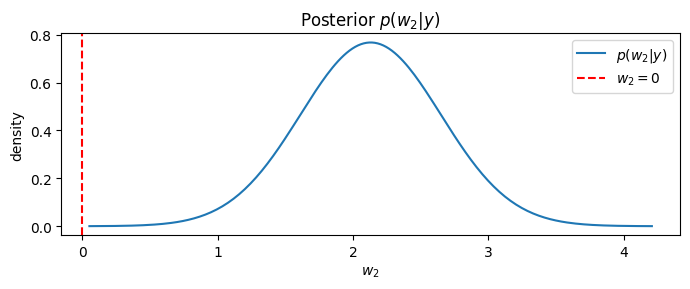

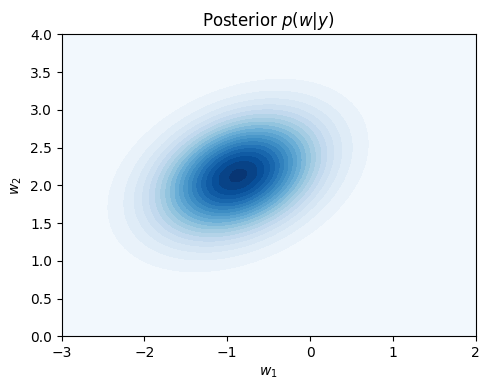

In [2]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from scipy.stats import norm, multivariate_normal as mvn
import numpy as np

# Plot a 1D Gaussian
mu, var = 2.13, 0.27
x_range = jnp.linspace(mu - 4*jnp.sqrt(var), mu + 4*jnp.sqrt(var), 200)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x_range, norm.pdf(x_range, loc=mu, scale=jnp.sqrt(var)), label='$p(w_2|y)$')
ax.axvline(0, color='r', linestyle='--', label='$w_2=0$')
ax.set(xlabel='$w_2$', ylabel='density', title='Posterior $p(w_2|y)$')
ax.legend(); plt.tight_layout(); plt.show()

# Plot a 2D Gaussian contour
m = jnp.array([-0.87, 2.13])
S = jnp.array([[0.41, 0.11], [0.11, 0.27]])

w1_range = jnp.linspace(-3, 2, 100)
w2_range = jnp.linspace(0, 4, 100)
W1, W2 = jnp.meshgrid(w1_range, w2_range)
pos = jnp.stack([W1, W2], axis=-1) # shape (100,100,2)

Z = mvn.pdf(np.array(pos), mean=np.array(m), cov=np.array(S))  # scipy needs numpy arrays

fig, ax = plt.subplots(figsize=(5, 4))
ax.contourf(W1, W2, Z, levels=20, cmap='Blues')
ax.set(xlabel='$w_1$', ylabel='$w_2$', title='Posterior $p(w|y)$')
plt.tight_layout(); plt.show()

<div class="alert alert-block alert-danger">

### **8. Dot products and dimensions**
</div>

In [ ]:
import jax.numpy as jnp

w = jnp.array([1.0, 2.0])          # shape (2,) ← 1D array (foretrækkes!)
x = jnp.array([0.0, 1.0])          # shape (2,)

# Dot product  w^T x  →  scalar
print(w @ x)                       # = 2.0  

# If vectors are column vectors shape (2,1):
w_col = jnp.array([[1.0], [2.0]])  # shape (2,1)
x_col = jnp.array([[0.0], [1.0]])  # shape (2,1)

print(w_col.T @ x_col)             # shape (1,1) - use [0,0] to get scalar
print((w_col.T @ x_col)[0,0])      # = 2.0  

# Quadratic form  x^T S x  →  scalar
S = jnp.array([[0.41, 0.11], [0.11, 0.27]])

print(x @ S @ x)                   # 1D arrays → scalar directly  
print((x_col.T @ S @ x_col)[0,0])  # column vectors → extract [0,0]  

# .T on a 1D array does NOTHING in JAX!
print(w.T.shape)    # still (2,) - .T only works on 2D+ arrays

<div class="alert alert-block alert-danger">

### **9. Entropy af mean-field Gaussian**
</div>



$$q(w) = \prod_{i=1}^D \mathcal{N}(w_i|\mu_i, v_i) \implies H[q] = \sum_{i=1}^D \frac{1}{2}\ln(2\pi e\, v_i)$$

In [ ]:
import jax.numpy as jnp

v = jnp.array([0.38, 0.19, 0.13, 0.09]) # variances (NOT std devs!)
H = jnp.sum(0.5 * jnp.log(2 * jnp.pi * jnp.e * v))
print(f'H[q] = {H:.4f}')

<div class="alert alert-block alert-danger">

### **10. Expected utility (decision theory)**
</div>



$$\mathbb{E}[\mathcal{U}(y^*, \hat{y})] = \sum_{y^*} p(y^*|y,x^*) \cdot \mathcal{U}(y^*, \hat{y})$$

Chose the decision $\hat{y}$ that maximizes the expected utility.

In [ ]:
import jax.numpy as jnp

p1 = 0.80   # p(y*=1 | y, x*)  ← from probit or plug-in
p0 = 1 - p1

# Utility matrix U[true, predicted]
# U[y*, y_hat]: row = true label, col = predicted label
U = jnp.array([[2, 1],    # true=0: predict 0 → 2, predict 1 → 1
               [1, 2]])   # true=1: predict 0 → 1, predict 1 → 2

EU_hat0 = p0 * U[0, 0] + p1 * U[1, 0]   # expected utility for predicting y_hat=0
EU_hat1 = p0 * U[0, 1] + p1 * U[1, 1]   # expected utility for predicting y_hat=1

print(f'E[U | y_hat=0] = {EU_hat0:.2f}')
print(f'E[U | y_hat=1] = {EU_hat1:.2f}')
print(f'Optimal decision: y_hat = {jnp.argmax(jnp.array([EU_hat0, EU_hat1]))}')

<div class="alert alert-block alert-danger">

### **11. Sampling and log-probabilities - the master decision tree**
</div>

Is our parameter $\theta$ a scalar (1D)?

>  Use log_npdf / norm

> Use mvn.logpdf / mvn.pdf

Is our likelihood Gaussian?

> log_npdf(y, mean, variance)

> Use poisson.logpmf, log_ber, etc.

Do we need to evaluate a density (not a probability)?

> Use .pdf() or log_npdf()

> Use .cdf() for P(X < x) or mean(samples < x)

Is the likelihood sum over N data points?

> Always .sum() the result!

> Single observation, no sum needed

<div class="alert alert-block alert-danger">

### **12. Sampling and log-probabilities - helper functions**
</div>

##### **Helper functions**

**log_npdf - 1D Gaussian log-density**

When: Parameter is scalar ($w \in \mathbb{R}$) OR evaluating a single $y$ given scalar mean:
$$
\log p(x | m, v) = -\frac{1}{2}\log(2\pi v) - \frac{(x-m)^2}{2v}
$$

PYTHON SCRIPT:

```python
log_npdf = lambda x, m, v: -0.5*np.log(2*np.pi*v) - 0.5*(x-m)**2/v

# USE WHEN: 1D parameter, single observation
log_prior = log_npdf(w, 0, 1)           # w ~ N(0,1)
log_lik   = log_npdf(y, f, sigma2)      # y ~ N(f, sigma²)

# USE WHEN: 2 independent params (w1, w2 both scalar)
log_prior = log_npdf(w[0], 0, 1) + log_npdf(w[1], 0, 1)
```




**DO NOT USE WHEN:** parameter is a vector! Use mvn.logpdf instead like:

2025R exam:
$$f(x) = w_2*\tanh(w_1*x)$$

Here, both $w_1,w_2$ scalar → log_npdf twice

**log_ber - Bernoulli log-likelihood**

When: Binary classification $y \in \{0,1\}$ with predicted probability $p$ so:
$$
\log p(y | p) = y·\log(p) + (1-y)·\log(1-p)
$$

PYTHON SCRIPT:

```python

log_ber = lambda y, p: y*np.log(np.clip(p,1e-12,1)) + (1-y)*np.log(np.clip(1-p,1e-12,1))

# USE WHEN: logistic regression / GP classification
p_n = sigmoid(w @ phi_n)
log_lik = sum(log_ber(y_n, p_n) for y_n, p_n in zip(y, probs))
```

**entropy - Categorical entropy**

When: Computing $H[\text{Cat}(\pi)]$ for discrete distributions
$$
H = -\sum_k \pi_k \log \pi_k
$$

```python
entropy = lambda p: -np.sum(p[p>0] * np.log(p[p>0]))

# USE WHEN: multi-class posterior predictive
pi = np.array([0.00, 0.27, 0.73])
H = entropy(pi)   # = 0.58
```

<div class="alert alert-block alert-danger">

### **13. Sampling and log-probabilities - scipy imports**
</div>

**norm vs mvn - THE most common mistake:**

| | `norm` (1D) | `mvn` (multivariate) |
|---|---|---|
| **When** | scalar $w \in \mathbb{R}$ | vector $w \in \mathbb{R}^D$, $D \geq 2$ |
| **Scale/cov input** | `scale=` **std dev** $\sqrt{v}$ (NOT variance!) | `cov=` **covariance matrix** $S$ |
| **Mean input** | `loc=scalar` | `mean=array` (use `.ravel()`!) |
| **2024R Q3.2** | WRONG | CORRECT ($\theta \in \mathbb{R}^2$) |
| **2025R Q5.1** | YES! if $w$ is scalar | YES! if $w$ is vector |

SCRIPT:
```python
from scipy.stats import norm
from scipy.stats import multivariate_normal as mvn

# norm: 1D, scale = STD DEV (NOT variance!)
norm.pdf(x, loc=mean, scale=np.sqrt(variance))
norm.logpdf(x, loc=mean, scale=np.sqrt(variance))
norm.cdf(x, loc=mean, scale=np.sqrt(variance))   # P(X ≤ x)

# mvn: multivariate, cov = COVARIANCE MATRIX
mvn.pdf(x_vec, mean=m.ravel(), cov=S)
mvn.logpdf(w.ravel(), mean=np.zeros(2), cov=1/alpha*np.eye(2))
# NOTE: always .ravel() column vectors before passing!
```

**poisson - Poisson log-likelihood**

When: Count data $y \in \{0,1,2,...\}$ with rate $\mu = \exp(\text{linear predictor})$

$$\log p(y|\mu) = y\log\mu - \mu - \log(y!)$$

```python
from scipy.stats import poisson

# ALWAYS .sum() over data points!
mu = jnp.exp(3 + w[0]*x + w[1]*x**2)    # rate (must be positive)
log_lik = poisson.logpmf(y, mu).sum()   # ← .sum() IS MANDATORY

# Common mistake: forgetting .sum()
# poisson.logpmf returns array of shape (N,) - NOT a scalar!
```



**mvn.logpdf - multivariate Gaussian log-prior**

When: Parameter $w \in \mathbb{R}^D$ with $D \geq 2$, Gaussian prior

$$\log p(w) = \log \mathcal{N}(w | 0, \alpha^{-1}I)$$

```python
from scipy.stats import multivariate_normal as mvn

# For w ∈ R² with prior N(0, α⁻¹I):
log_prior = mvn.logpdf(w, mean=np.zeros(2), cov=1/alpha * np.eye(2))

# KEY: mvn.logpdf returns a SCALAR - no .sum() needed for the prior
# 2024R Q4.3: prior on w = [w1, w2] ∈ R²
```

<div class="alert alert-block alert-danger">

### **14. Sampling and log-probabilities - sampling**
</div>

```python
# Sample from 1D Gaussian N(μ, σ²)
# When: scalar parameter or 1D predictions
key = random.PRNGKey(0)
samples = mean + jnp.sqrt(variance) * random.normal(key, shape=(S,))
# Reparameterization trick: w = μ + √v · ε,  ε ~ N(0,1)
``` 

```python
# Sample from Multivariate Gaussian N(m, S)
# When: vector parameter w ∈ R^D, posterior samples
key = random.PRNGKey(0)
w_samples = random.multivariate_normal(key, mean=m.ravel(), cov=S, shape=(S_samples,))
# w_samples has shape (S_samples, D)
# Access: w1_samples = w_samples[:, 0],  w2_samples = w_samples[:, 1]
```

```python
# Sample from Poisson(μ) 
# When: posterior predictive y* for count data
# NEEDS NUMPY - not JAX!
mu_star_samples = jnp.exp(3 + w_samples[:,0]*x_star + w_samples[:,1]*x_star**2)
y_star_samples  = np.random.poisson(np.array(mu_star_samples))
lower, upper = jnp.percentile(jnp.array(y_star_samples), jnp.array([5, 95]))
# 2024R Q4.6: 90% credibility interval for y*
```

```python
# Sample from Beta(a, b)
# When: θ ∈ [0,1] from beta-binomial model
from scipy.stats import beta as beta_dist
samples = beta_dist.rvs(a=alpha_n, b=beta_n, size=S)
```

```python   
# Ancestral sampling - prior predictive
# When: sampling p(y*) by first sampling parameters
# Step 1: sample parameters from prior
w_samples = random.normal(key, shape=(S,))        # w ~ N(0,1)
# Step 2: sample observations given parameters
y_samples = jnp.exp(w_samples) + jnp.sqrt(1.0) * random.normal(key, shape=(S,))
E_y = jnp.mean(y_samples)   # prior mean of y
# 2024R Q5.1: prior mean of y using ancestral sampling
```


<div class="alert alert-block alert-danger">

### **15. Sampling and log-probabilities - metropolis**
</div>

```python
# Pattern 1: Scalar params, Gaussian likelihood (2025R style)
# f(x) = w2*tanh(w1*x),  y ~ N(f, σ²)
def log_target(w):
    f         = w[1] * jnp.tanh(w[0] * x1)
    log_lik   = log_npdf(y1, f, sigma2)                       # scalar y, scalar f
    log_prior = log_npdf(w[0], 0, 1) + log_npdf(w[1], 0, 1)  # each w scalar
    return log_lik + log_prior   # MUST return a scalar
```

```python
# Pattern 2: Vector params, non-Gaussian likelihood (2024R style)
# μ(x) = exp(3 + w1*x + w2*x²),  y ~ Poisson(μ)
def log_target(w):
    mu        = jnp.exp(3 + w[0]*x + w[1]*x**2)
    log_lik   = poisson.logpmf(y, mu).sum()                   # .sum() over N points!
    log_prior = mvn.logpdf(w, np.zeros(2), 1/alpha*np.eye(2)) # w is 2D vector
    return log_lik + log_prior
```



**Choosing the right log_prior:**

| Scenario | Code | Why |
|---|---|---|
| $w \in \mathbb{R}$, prior $\mathcal{N}(0,1)$ | `log_npdf(w, 0, 1)` | scalar param |
| $w_1, w_2 \in \mathbb{R}$ independent | `log_npdf(w[0],0,1) + log_npdf(w[1],0,1)` | sum of independent |
| $w \in \mathbb{R}^2$, prior $\mathcal{N}(0,\alpha^{-1}I)$ | `mvn.logpdf(w, zeros(2), 1/α·I)` | vector param |



**Choosing the right log_likelihood:**

| Model | Code | Note |
|---|---|---|
| $y \sim \mathcal{N}(f, \sigma^2)$, scalar | `log_npdf(y, f, sigma2)` | no sum needed |
| $y \in \mathbb{R}^N \sim \mathcal{N}(Xw, \sigma^2 I)$ | `sum(log_npdf(yn,fn,s2) for ...)` | N observations |
| $y \sim \text{Bernoulli}(\sigma(f))$ | `log_ber(y, sigmoid(f))` | clip away 0/1 |
| $y \sim \text{Poisson}(\exp(f))$ | `poisson.logpmf(y, mu).sum()` | `.sum()` always! |
| $y \sim \text{Cat}(\text{softmax}(f))$ | `sum(yn·log(πn))` | multi-class |


<div class="alert alert-block alert-danger">

### **16. Sampling and log-probabilities - quick reference**
</div>


| Task | Use | Gotcha |
|---|---|---|
| log prior, scalar $w$ | `log_npdf(w, 0, 1/α)` | $v$ = variance, not std! |
| log prior, vector $w$ | `mvn.logpdf(w, zeros, 1/α·I)` | $w$ must be 1D array |
| log lik, Gaussian | `log_npdf(y, f, σ²)` | single obs only |
| log lik, Poisson | `poisson.logpmf(y,μ).sum()` | **ALWAYS** `.sum()`! |
| log lik, Bernoulli | `log_ber(y, p)` | clip $p$ away from 0/1 |
| evaluate prior density | `mvn.pdf(θ, m, S)` | `.ravel()` if needed |
| sample $\mathcal{N}(\mu,\sigma^2)$ scalar | `μ + √v·random.normal(key,(S,))` | $\sqrt{v}$ not $v$ |
| sample $\mathcal{N}(m,S)$ vector | `random.multivariate_normal(key,m,S,(S,))` | shape=$(S,D)$ |
| sample Poisson($\mu$) | `np.random.poisson(mu_samples)` | needs numpy! |
| $P(w > 0)$ from samples | `jnp.mean(samples[:,0] > 0)` | indicator function |
| 90% CI from samples | `jnp.percentile(s, [5, 95])` | 5% each tail |
| design matrix | `jnp.column_stack([ones(N), x, x**2])` | don't forget bias! |
| normal equations | `jnp.linalg.solve(Phi.T@Phi, Phi.T@y)` | use solve not inv |
| JAX 64-bit | `jax.config.update("jax_enable_x64", True)` | put at top always! |

<div class="alert alert-block alert-warning">

### **Fast references, the most important formulas**
</div>


##### **Linear Gaussian Systems**



$$p(y|z) = \mathcal{N}(y|Wz+b, \Sigma_y), \quad p(z) = \mathcal{N}(z|\mu_z, \Sigma_z)$$
$$p(y) = \mathcal{N}(y|W\mu_z+b,\; \Sigma_y + W\Sigma_z W^T) \quad\text{(marginal)}$$
$$\Sigma_{z|y}^{-1} = \Sigma_z^{-1} + W^T\Sigma_y^{-1}W, \quad \mu_{z|y} = \Sigma_{z|y}[W^T\Sigma_y^{-1}(y-b)+\Sigma_z^{-1}\mu_z] \quad\text{(posterior)}$$


##### **Bayesian Linear Regression**



$$p(w|y) = \mathcal{N}(w|m,S), \quad S=(\beta\Phi^T\Phi+\alpha I)^{-1}, \quad m=\beta S\Phi^T y$$
$$p(f^*|y,x^*) = \mathcal{N}(f^*|m^T\phi^*, \phi^{*T}S\phi^*)$$
$$p(y^*|y,x^*) = \mathcal{N}(y^*|m^T\phi^*, \phi^{*T}S\phi^* + \sigma^2)$$


##### **Laplace + Probit (classification)**


$$S=(-H)^{-1}, \quad p(y^*=1|y,x^*) \approx \Phi\!\left(\frac{\mu_{f^*}}{\sqrt{8/\pi + \sigma^2_{f^*}}}\right)$$


##### **GP Regression**




$$\mu_{f^*|y} = k_*(K+\sigma^2 I)^{-1}y, \quad \sigma^2_{f^*|y}=k_{**} - k_*(K+\sigma^2 I)^{-1}k_*^T$$
$$\log p(y|\theta) = -\tfrac{N}{2}\log(2\pi) - \tfrac{1}{2}\log|K+\sigma^2 I| - \tfrac{1}{2}y^T(K+\sigma^2 I)^{-1}y$$